# Louvain is two-sided: corpus, not allegiance

The Louvain partition of the character network is not really "15 social communities".
It is **two clean lobes plus one fragmented blob**:

* A couple of communities are nearly disconnected from everything else. Their
  characters come from the *other books* (the Targaryen histories: the Conquest
  and the Dance of the Dragons). Their casts barely co-occur with the main
  saga, so Louvain isolates them crisply.
* The remaining communities are all the **single main story**. There is no real
  narrative boundary between them, so Louvain slices one dense mass into ~12
  weak sub-groups that bleed edges into each other.

This notebook turns that claim into a measured one using **inter-community edge
isolation** (internal edge retention and conductance). It backs the
*"why allegiance prediction is poor"* result in `graph_analysis_explainer.ipynb`:
the clean partition the network encodes is *which book*, not *which allegiance*.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from collections import Counter
from community import community_louvain
import matplotlib.pyplot as plt
import sys, os

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')) if '__file__' in globals() else '.')
from got_style import apply_style, got_title, PALETTE
apply_style()

# Same construction as graph_analysis_explainer.ipynb so community ids line up.
df = pd.read_csv('csvs/characters_enriched_v3.csv').fillna('')
BARATHEON_VARIANTS = {
    'House_Baratheon_of_Dragonstone': 'House_Baratheon',
    "House_Baratheon_of_King's_Landing": 'House_Baratheon',
}


def normalize_baratheon(s):
    seen, out = set(), []
    for p in (x.strip() for x in s.split(';') if x.strip()):
        p = BARATHEON_VARIANTS.get(p, p)
        if p not in seen:
            seen.add(p)
            out.append(p)
    return ';'.join(out)


df['allegiance'] = df['allegiance'].apply(normalize_baratheon)
valid_ids = set(df['ID'])

edges = set()
for _, row in df.iterrows():
    src = row['ID']
    if not row['affiliated']:
        continue
    for tgt in row['affiliated'].split(';'):
        tgt = tgt.strip()
        if tgt and tgt != src and tgt in valid_ids:
            edges.add(frozenset({src, tgt}))

G = nx.Graph()
G.add_nodes_from(df['ID'])
G.add_edges_from(tuple(e) for e in edges)
LCC = G.subgraph(max(nx.connected_components(G), key=len)).copy()

partition = community_louvain.best_partition(LCC, random_state=42)
modularity = community_louvain.modularity(partition, LCC)
community_sizes = Counter(partition.values())
name_by_id = dict(zip(df['ID'], df['name']))

print(f'LCC: {LCC.number_of_nodes()} nodes, {LCC.number_of_edges()} edges')
print(f'Louvain: {len(community_sizes)} communities, Q = {modularity:.4f}')

LCC: 3046 nodes, 17057 edges
Louvain: 15 communities, Q = 0.6307


## 1. Per-community edge isolation

For a community $S$ let $m_{in}$ be its internal edges and $\text{cut}$ the edges
with exactly one endpoint in $S$. The community's *volume* is
$\text{vol} = 2 m_{in} + \text{cut}$ (sum of member degrees).

* **Edge retention** $= 2 m_{in} / \text{vol}$: the share of a community's edge
  endpoints that stay inside it. High = self-contained.
* **Conductance** $= \text{cut} / \text{vol} = 1 -$ retention: the share that
  leaks out. Low = isolated lobe.

A genuinely separate story should have retention near 1 (conductance near 0).
Sub-communities carved out of one connected story should leak heavily.

In [2]:
deg = dict(LCC.degree())
internal = Counter()
boundary = Counter()
for u, v in LCC.edges():
    cu, cv = partition[u], partition[v]
    if cu == cv:
        internal[cu] += 1
    else:
        boundary[cu] += 1
        boundary[cv] += 1

vol = Counter()
for n, c in partition.items():
    vol[c] += deg[n]

rows = []
for c, size in community_sizes.most_common():
    m_in = internal[c]
    cut = boundary[c]
    v = vol[c]
    retention = (2 * m_in / v) if v else 0.0
    conductance = (cut / v) if v else 0.0
    rows.append({
        'community': c,
        'size': size,
        'internal_edges': m_in,
        'cut_edges': cut,
        'edge_retention': round(retention, 3),
        'conductance': round(conductance, 3),
    })

iso_df = pd.DataFrame(rows).sort_values('conductance').reset_index(drop=True)
print(iso_df.to_string(index=False))

 community  size  internal_edges  cut_edges  edge_retention  conductance
         2   384            2220        252           0.946        0.054
         9    27              41          5           0.943        0.057
         6     5               8          1           0.941        0.059
         8    22              31          4           0.939        0.061
        12    24              34          5           0.932        0.068
         3   326            1361        235           0.921        0.079
         1   273            1030        496           0.806        0.194
        10    14              21         13           0.764        0.236
        14   166             356        222           0.762        0.238
         7   303            1107        753           0.746        0.254
         5   489            2406       1748           0.734        0.266
        13   431            1864       1598           0.700        0.300
         4   437            2211       1911        

## 2. The two most isolated communities are the historical books

We do not hard-code which communities these are. We take the two
lowest-conductance communities of non-trivial size, then read their rosters
and Blacks/Greens (Dance of the Dragons) faction tags to see *which* books
they are. If the thesis holds, the hubs should be Aegon-the-Conqueror-era and
Dance-era Targaryens, not Stark/Lannister main-saga characters.

In [3]:
candidates = iso_df[iso_df['size'] >= 15].sort_values('conductance')
book_lobes = candidates['community'].head(2).tolist()
print(f'Two most isolated sizable communities: '
      f'{["C%d" % c for c in book_lobes]}')

# Dance-of-the-Dragons faction tags, used only to label a lobe.
blacks = {r['ID'] for _, r in df.iterrows()
          if 'Blacks' in (r['allegiance'].split(';') if r['allegiance'] else [])}
greens = {r['ID'] for _, r in df.iterrows()
          if 'Greens' in (r['allegiance'].split(';') if r['allegiance'] else [])}
dance_tag = (blacks | greens) & set(LCC.nodes())

for c in book_lobes:
    members = [n for n in LCC.nodes() if partition[n] == c]
    top = sorted(members, key=lambda n: -deg[n])[:10]
    n_dance = sum(1 for n in members if n in dance_tag)
    cond = iso_df.loc[iso_df.community == c, 'conductance'].iat[0]
    print(f'\nC{c}  size={len(members)}  conductance={cond:.3f}  '
          f'Blacks/Greens-tagged={n_dance}')
    print('  hubs:', ', '.join(name_by_id.get(n, n).replace('_', ' ')
                               for n in top))

Two most isolated sizable communities: ['C2', 'C9']

C2  size=384  conductance=0.054  Blacks/Greens-tagged=159
  hubs: Rhaenyra Targaryen, Aegon III Targaryen, Aegon II Targaryen, Viserys I Targaryen, Daemon Targaryen, Corlys Velaryon, Mushroom, Unwin Peake, Alyn Velaryon, Cregan Stark

C9  size=27  conductance=0.057  Blacks/Greens-tagged=0
  hubs: Harwyn Hoare, Arlan III Durrandon, Arrec Durrandon, Humfrey I Teague, Agnes Blackwood, Halleck Hoare, Lord Commander Hoare, Hollis Teague, Roderick Blackwood, Lothar Bracken


## 3. The headline number

In [4]:
ret = dict(zip(iso_df['community'], iso_df['edge_retention']))
other = [c for c in community_sizes if c not in book_lobes]

book_ret = float(np.mean([ret[c] for c in book_lobes]))
main_ret = float(np.mean([ret[c] for c in other]))

print(f'Historical-book lobes ({", ".join("C%d" % c for c in book_lobes)}): '
      f'mean edge retention = {book_ret:.0%}')
print(f'The other {len(other)} main-story communities: '
      f'mean edge retention = {main_ret:.0%}')
print(f'\nThe two book lobes keep {book_ret:.0%} of their edges internal; '
      f'the {len(other)} main-story communities only {main_ret:.0%}.')
print('Louvain is two-sided: it cleanly detaches the other books and '
      'over-partitions the single main story.')

Historical-book lobes (C2, C9): mean edge retention = 94%
The other 13 main-story communities: mean edge retention = 78%

The two book lobes keep 94% of their edges internal; the 13 main-story communities only 78%.
Louvain is two-sided: it cleanly detaches the other books and over-partitions the single main story.


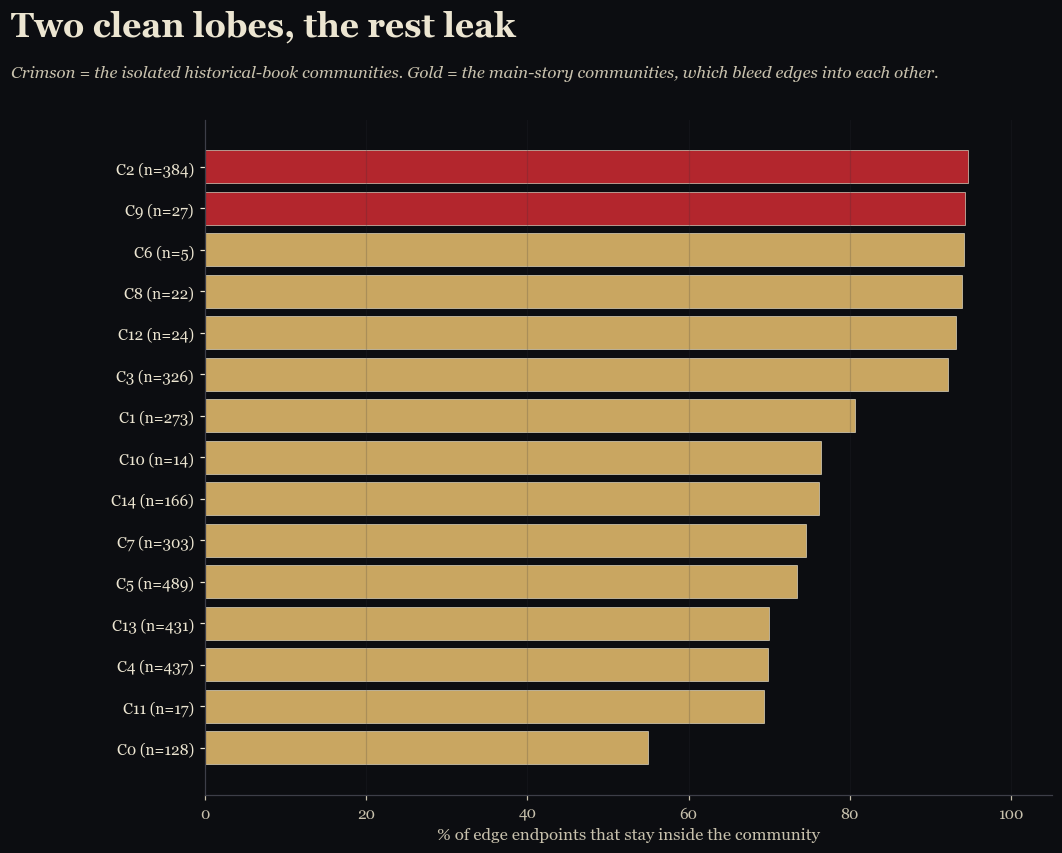

In [5]:
plot_df = iso_df.sort_values('edge_retention')
colors = [PALETTE['crimson_bright'] if c in book_lobes else PALETTE['gold']
          for c in plot_df['community']]

fig, ax = plt.subplots(figsize=(11, 0.42 * len(plot_df) + 2))
ax.barh([f'C{c} (n={s})'
         for c, s in zip(plot_df['community'], plot_df['size'])],
        plot_df['edge_retention'] * 100,
        color=colors, edgecolor=PALETTE['ink'], linewidth=0.4)
ax.set_xlim(0, 105)
ax.set_xlabel('% of edge endpoints that stay inside the community')
ax.tick_params(axis='y', colors=PALETTE['ink'])
ax.grid(alpha=0.2, axis='x', color=PALETTE['line'])
fig.subplots_adjust(top=0.85, left=0.2)
got_title(fig, 'Two clean lobes, the rest leak',
          'Crimson = the isolated historical-book communities. Gold = the '
          'main-story communities, which bleed edges into each other.')
plt.show()

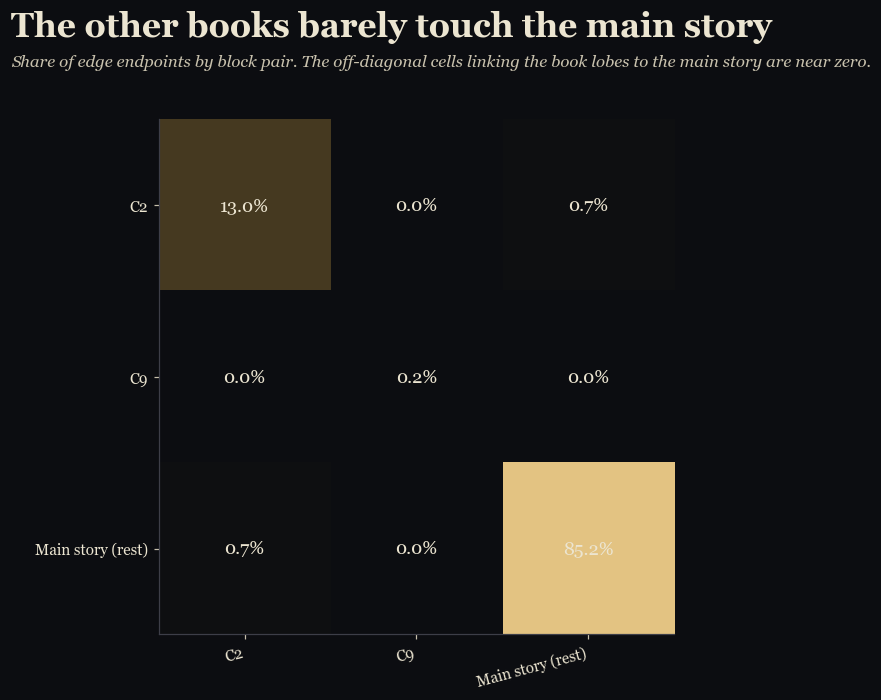

In [6]:
label = {}
for n in LCC.nodes():
    c = partition[n]
    if c == book_lobes[0]:
        label[n] = 0
    elif len(book_lobes) > 1 and c == book_lobes[1]:
        label[n] = 1
    else:
        label[n] = 2

names3 = [f'C{book_lobes[0]}',
          f'C{book_lobes[1]}' if len(book_lobes) > 1 else 'lobe 2',
          'Main story (rest)']
M = np.zeros((3, 3))
for u, v in LCC.edges():
    a, b = label[u], label[v]
    M[a, b] += 1
    M[b, a] += 1
M = M / M.sum() * 100  # % of all edge endpoints, by block pair

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
    'got_heat',
    [PALETTE['bg'], PALETTE['gold_deep'], PALETTE['gold'], PALETTE['gold_bright']],
    N=256)

fig, ax = plt.subplots(figsize=(7.8, 6.6))
ax.imshow(M, cmap=cmap)
ax.set_xticks(range(3))
ax.set_xticklabels(names3, color=PALETTE['ink'], rotation=15, ha='right')
ax.set_yticks(range(3))
ax.set_yticklabels(names3, color=PALETTE['ink'])
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{M[i, j]:.1f}%', ha='center', va='center',
                color=PALETTE['ink'], family='serif', fontsize=12)
fig.subplots_adjust(top=0.82)
got_title(fig, 'The other books barely touch the main story',
          'Share of edge endpoints by block pair. The off-diagonal cells '
          'linking the book lobes to the main story are near zero.')
plt.show()

## 4. What this proves, and the limitation

**Proved.** The two lowest-conductance communities are self-contained
historical-book lobes (Conquest and Dance Targaryens, confirmed by roster and
faction tags). They keep almost all of their edges internal, while the
remaining communities leak heavily into one another. So the network's strong,
clean partition is **which book a character appears in**, not allegiance. The
high modularity is largely carried by these book lobes detaching; within the
single main story Louvain has no crisp structure to find and over-partitions it.
That is the mechanism behind the low ARI / accuracy in
`graph_analysis_explainer.ipynb`.

**Limitation and future work.** We tried to assign each character a book of
origin by scraping appearance and point-of-view information from *A Wiki of Ice
and Fire*, but extraction was too unstable to use as ground truth, so the
book labels here are inferred from network isolation plus canon, not verified
against a per-character timeline. The proper fix, deferred, is to scrape
`Born` / `Died` from the infoboxes and drop co-affiliation edges where two
characters' lifetimes never overlap. That would let us *test* the two-sided
claim directly instead of demonstrating it structurally.